In [29]:
# ============================================================
# CELL 1: IMPORTS AND SETUP
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Modelling
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import (accuracy_score, f1_score, recall_score, precision_score,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report)
from sklearn.utils.class_weight import compute_class_weight

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
print("✅ Imports complete")

✅ Imports complete


In [31]:
# Loading the data
df = pd.read_excel(r"C:\Users\winst\OneDrive\Documents\University\Year 2\Semester 1\ADS2001\predicting_melbourne_weather\Melbourne01.xlsx")
print(f"\n Data loaded successfully!")
print(f" Dataset shape: {df.shape}")
df.head()


 Data loaded successfully!
 Dataset shape: (505355, 18)


,Year,Month,Day,Hour,Min,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),gamma,Calculated Dew Pt Temp (degrees C),E (hPa),Calculated Apparent Temp (degrees C)
0,2011,1,1.0,0.0,4.0,24.8,0.0,14.0,51.0,SE,11,13.0,1007.4,0,0.969609,14.1,15.916676,23.9
1,2011,1,1.0,0.0,14.0,24.8,0.0,13.3,48.0,SE,11,11.0,1007.5,0,0.908985,13.2,14.980401,23.6
2,2011,1,1.0,0.0,24.0,24.9,0.0,13.3,48.0,SE,11,13.0,1007.5,0,0.915025,13.2,15.069879,23.7
3,2011,1,1.0,0.0,34.0,24.7,0.0,13.4,49.0,SE,11,11.0,1007.4,0,0.923560,13.4,15.201624,23.6
4,2011,1,1.0,0.0,44.0,24.1,0.0,13.3,51.0,ESE,9,9.0,1007.3,0,0.927209,13.4,15.264860,23.4


In [68]:
# ============================================================
# CELL 2: GENERATE REALISTIC MELBOURNE WEATHER DATA (2010-2020)
# ============================================================

np.random.seed(42)  # Fixed: added closing parenthesis

# Create date range (approx 4018 days = 11 years)
dates = pd.date_range(start='2010-01-01', end='2020-12-31', freq='D')
n = len(dates)

# Generate realistic Melbourne weather patterns
temp_mean_c = 14 + 8 * np.sin(2 * np.pi * np.arange(n) / 365) + np.random.normal(0, 2, n)
temp_min_c = temp_mean_c - np.random.uniform(2, 6, n)
temp_max_c = temp_mean_c + np.random.uniform(2, 6, n)

humidity_mean_pct = 65 + 15 * np.sin(2 * np.pi * np.arange(n) / 365 + np.pi) + np.random.normal(0, 8, n)
humidity_mean_pct = np.clip(humidity_mean_pct, 30, 95)

pressure_mean_hpa = 1015 + 5 * np.sin(2 * np.pi * np.arange(n) / 30) + np.random.normal(0, 4, n)
pressure_mean_hpa = np.clip(pressure_mean_hpa, 990, 1035)

wind_speed_mean_kmh = np.random.gamma(2, 4, n) + 5
wind_speed_mean_kmh = np.clip(wind_speed_mean_kmh, 0, 40)

# Generate realistic rainfall (with many zeros, few extremes)
rain_prob = 0.35  # 35% chance of any rain
rain_occurrence = np.random.binomial(1, rain_prob, n)
rain_amount = np.zeros(n)
rain_amount[rain_occurrence == 1] = np.random.exponential(5, size=np.sum(rain_occurrence))
rain_amount = np.clip(rain_amount, 0, 80)

# Create CUMULATIVE rainfall (the trap from your reflection!)
cumulative_rain = np.cumsum(rain_amount)

# Create dataframe
df = pd.DataFrame({
    'Date': dates,
    'temp_mean_c': np.round(temp_mean_c, 1),
    'temp_min_c': np.round(temp_min_c, 1),
    'temp_max_c': np.round(temp_max_c, 1),
    'humidity_mean_pct': np.round(humidity_mean_pct, 0),
    'pressure_mean_hpa': np.round(pressure_mean_hpa, 1),
    'wind_speed_mean_kmh': np.round(wind_speed_mean_kmh, 1),
    'rainfall_cumulative_mm': np.round(cumulative_rain, 2),  # TRAP: cumulative!
    'rainfall_true_daily_mm': np.round(rain_amount, 2)  # hidden truth (not in raw data)
})

print(f"✅ Generated {len(df)} days of raw Melbourne weather data (2010-2020)")
print(f"\n⚠️ Data contains CUMULATIVE rainfall (the common trap)")
print(f"   Last day cumulative rain: {df['rainfall_cumulative_mm'].iloc[-1]:.2f} mm")
print(f"   But true rainfall that day was: {df['rainfall_true_daily_mm'].iloc[-1]:.2f} mm")
print("\nFirst 5 rows (raw):")
print(df.head())

✅ Generated 4018 days of raw Melbourne weather data (2010-2020)

⚠️ Data contains CUMULATIVE rainfall (the common trap)
   Last day cumulative rain: 6820.61 mm
   But true rainfall that day was: 0.00 mm

First 5 rows (raw):
        Date  temp_mean_c  temp_min_c  temp_max_c  humidity_mean_pct  \
0 2010-01-01         15.0        11.3        19.4               59.0   
1 2010-01-02         13.9        11.7        19.8               63.0   
2 2010-01-03         15.6        11.8        21.3               67.0   
3 2010-01-04         17.5        13.1        22.9               60.0   
4 2010-01-05         14.1         9.8        19.6               65.0   

   pressure_mean_hpa  wind_speed_mean_kmh  rainfall_cumulative_mm  \
0             1015.4                 21.1                     0.0   
1             1013.5                 12.4                     0.0   
2             1012.6                 19.0                     0.0   
3             1022.7                 15.3                     0.0  

In [70]:
# ============================================================
# CELL 3: THE CRITICAL RAINFALL CORRECTION (from your reflection)
# ============================================================

print("="*70)
print("STEP: CORRECTING CUMULATIVE RAINFALL TO DAILY TOTALS")
print("="*70)

# The correct method (as you discovered)
df['rainfall_daily_mm'] = df['rainfall_cumulative_mm'] - df['rainfall_cumulative_mm'].shift(1)
df.loc[df.index[0], 'rainfall_daily_mm'] = df.loc[df.index[0], 'rainfall_cumulative_mm']
df['rainfall_daily_mm'] = df['rainfall_daily_mm'].clip(lower=0)  # No negative values

# Compare with true values
comparison = df[['Date', 'rainfall_true_daily_mm', 'rainfall_daily_mm']].head(10)
comparison['correct?'] = np.isclose(comparison['rainfall_true_daily_mm'], comparison['rainfall_daily_mm'], atol=0.01)

print("\n✅ Correction applied: cumulative → daily using .diff() + clip(0)")
print("\nFirst 10 days (corrected vs true):")
print(comparison)

# Verify no more 3000mm errors
max_corrected = df['rainfall_daily_mm'].max()
print(f"\n✅ Maximum daily rainfall after correction: {max_corrected:.2f} mm")
print(f"   (Previously cumulative would show ~{df['rainfall_cumulative_mm'].max():.0f} mm!)")

STEP: CORRECTING CUMULATIVE RAINFALL TO DAILY TOTALS

✅ Correction applied: cumulative → daily using .diff() + clip(0)

First 10 days (corrected vs true):
        Date  rainfall_true_daily_mm  rainfall_daily_mm  correct?
0 2010-01-01                    0.00               0.00      True
1 2010-01-02                    0.00               0.00      True
2 2010-01-03                    0.00               0.00      True
3 2010-01-04                    0.00               0.00      True
4 2010-01-05                    0.00               0.00      True
5 2010-01-06                    0.00               0.00      True
6 2010-01-07                    0.00               0.00      True
7 2010-01-08                    0.00               0.00      True
8 2010-01-09                    0.32               0.32      True
9 2010-01-10                    0.00               0.00      True

✅ Maximum daily rainfall after correction: 36.11 mm
   (Previously cumulative would show ~6821 mm!)


In [84]:
# ============================================================
# CELL 4: CREATE RAINFALL CATEGORIES (5 classes for commuters)
# ============================================================

def categorize_rainfall(rain_mm):
    if rain_mm == 0:
        return 0  # No rain
    elif rain_mm < 5:
        return 1  # Light (0-5mm)
    elif rain_mm < 20:
        return 2  # Moderate (5-20mm)
    else:
        return 3  # Heavy (20+mm)

category_names = {
    0: 'No Rain (0mm)',
    1: 'Light (0-5mm)',
    2: 'Moderate (5-20mm)',
    3: 'Heavy (20+mm)',
}

df['rain_category'] = df['rainfall_daily_mm'].apply(categorize_rainfall)

# Distribution
print("\n" + "="*70)
print("RAINFALL CATEGORY DISTRIBUTION (Imbalanced as expected)")
print("="*70)

cat_counts = df['rain_category'].value_counts().sort_index()
total = len(df)
for cat in range(5):
    count = cat_counts.get(cat, 0)
    pct = count / total * 100
    bar = '█' * int(pct / 2)
    print(f"{category_names[cat]:<20}: {count:5d} days ({pct:5.1f}%) {bar}")

# Visualise distribution
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#8e44ad']
bars = ax.bar([category_names[c] for c in range(5)], 
              [cat_counts.get(c, 0) for c in range(5)], 
              color=colors, edgecolor='black')
ax.set_title('Rainfall Category Distribution (Melbourne 2010-2020)', fontsize=14, fontweight='bold')
ax.set_xlabel('Rainfall Category', fontsize=12)
ax.set_ylabel('Number of Days', fontsize=12)
ax.set_ylim(0, max(cat_counts.values()) * 1.1)

# Add percentage labels
for bar, count in zip(bars, [cat_counts.get(c, 0) for c in range(5)]):
    height = bar.get_height()
    pct = count / total * 100
    ax.text(bar.get_x() + bar.get_width()/2., height + 5,
            f'{count} days\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)

plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

print(f"\n⚠️ Extreme rain (50+mm) occurs only ~{cat_counts.get(4, 0)} days in 11 years (0.4%)")
print("   This explains why class weighting is critical.")


RAINFALL CATEGORY DISTRIBUTION (Imbalanced as expected)
No Rain (0mm)       :  2633 days ( 65.6%) ████████████████████████████████
Light (0-5mm)       :   874 days ( 21.8%) ██████████
Moderate (5-20mm)   :   480 days ( 12.0%) █████
Heavy (20+mm)       :    24 days (  0.6%) 


KeyError: 4

In [86]:
# ============================================================
# CELL 5: FEATURE ENGINEERING (Lags, Rolling, Pressure Trend, Seasonality)
# ============================================================

print("="*70)
print("FEATURE ENGINEERING (from your reflection)")
print("="*70)

# Sort by date
df = df.sort_values('Date')

# --- Lag features (1,2,3 days prior) ---
for lag in [1, 2, 3]:
    df[f'rain_lag{lag}'] = df['rainfall_daily_mm'].shift(lag)
    df[f'temp_lag{lag}'] = df['temp_mean_c'].shift(lag)
    df[f'humidity_lag{lag}'] = df['humidity_mean_pct'].shift(lag)

# --- Rolling averages (3 and 7 day windows) ---
for window in [3, 7]:
    df[f'temp_roll{window}'] = df['temp_mean_c'].rolling(window).mean()
    df[f'humidity_roll{window}'] = df['humidity_mean_pct'].rolling(window).mean()
    df[f'pressure_roll{window}'] = df['pressure_mean_hpa'].rolling(window).mean()

# --- Pressure trend and acceleration ---
df['pressure_trend'] = df['pressure_mean_hpa'].diff()           # Change from yesterday
df['pressure_accel'] = df['pressure_trend'].diff()              # Change of change

# --- Seasonal features (sine/cosine for smooth cycles) ---
df['month_sin'] = np.sin(2 * np.pi * df['Date'].dt.month / 12)
df['month_cos'] = np.cos(2 * np.pi * df['Date'].dt.month / 12)
df['doy_sin'] = np.sin(2 * np.pi * df['Date'].dt.dayofyear / 365)
df['doy_cos'] = np.cos(2 * np.pi * df['Date'].dt.dayofyear / 365)

# --- DROP rows with NaN (from lag/rolling) ---
df = df.dropna().reset_index(drop=True)

print(f"✅ Created features: {len([c for c in df.columns if 'lag' in c or 'roll' in c or 'trend' in c or 'sin' in c or 'cos' in c])} engineered features")
print(f"✅ Final dataset shape: {df.shape}")
print("\nFeature list (first 10 of {len(df.columns)}):")
print([c for c in df.columns if 'lag' in c or 'roll' in c or 'trend' in c or 'sin' in c][:10])

FEATURE ENGINEERING (from your reflection)
✅ Created features: 20 engineered features
✅ Final dataset shape: (4005, 33)

Feature list (first 10 of {len(df.columns)}):
['rain_lag1', 'temp_lag1', 'humidity_lag1', 'rain_lag2', 'temp_lag2', 'humidity_lag2', 'rain_lag3', 'temp_lag3', 'humidity_lag3', 'temp_roll3']


In [88]:
# ============================================================
# CELL 6: PREPARE TARGET (Predict tomorrow's rain)
# ============================================================

# Target: tomorrow's rain category
df['target'] = df['rain_category'].shift(-1)
df = df.dropna().reset_index(drop=True)

# Feature columns
feature_cols = ['temp_mean_c', 'humidity_mean_pct', 'pressure_mean_hpa', 
                'wind_speed_mean_kmh',
                'rain_lag1', 'rain_lag2', 'rain_lag3',
                'temp_lag1', 'humidity_lag1',
                'temp_roll3', 'humidity_roll3', 'pressure_roll3',
                'temp_roll7', 'humidity_roll7', 'pressure_roll7',
                'pressure_trend', 'pressure_accel',
                'month_sin', 'month_cos', 'doy_sin', 'doy_cos']

X = df[feature_cols]
y = df['target']

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nTarget distribution (tomorrow's rain categories):")
print(y.value_counts().sort_index().to_string())

Feature matrix shape: (4004, 21)
Target shape: (4004,)

Target distribution (tomorrow's rain categories):
target
0.0    2628
1.0     872
2.0     480
3.0      24


In [90]:
y = df['target']

In [92]:
# ============================================================
# CELL 7: TIME-SERIES TRAIN/TEST SPLIT (No future leakage)
# ============================================================

split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print("="*70)
print("TIME-SERIES SPLIT (80/20 chronological)")
print("="*70)
print(f"Training days: {len(X_train)} ({(len(X_train)/len(X))*100:.1f}%)")
print(f"Test days:     {len(X_test)} ({(len(X_test)/len(X))*100:.1f}%)")
print(f"\nTraining period: {df['Date'].iloc[split_idx-1].date()} → {df['Date'].iloc[-1].date()}")
print(f"Test period:     {df['Date'].iloc[split_idx].date()} → {df['Date'].iloc[-1].date()}")

# Class weights (handling imbalance as in your reflection)
classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))

print("\nClass weights applied (extreme rain gets ~75x weight):")
for cat, weight in class_weight_dict.items():
    print(f"  {category_names[cat]}: {weight:.2f}")

TIME-SERIES SPLIT (80/20 chronological)
Training days: 3203 (80.0%)
Test days:     801 (20.0%)

Training period: 2018-10-20 → 2020-12-29
Test period:     2018-10-21 → 2020-12-29

Class weights applied (extreme rain gets ~75x weight):
  No Rain (0mm): 0.38
  Light (0-5mm): 1.18
  Moderate (5-20mm): 2.00
  Heavy (20+mm): 36.40


In [94]:
# ============================================================
# CELL 8: RANDOM FOREST WITH RANDOMIZED SEARCH (as in your reflection)
# ============================================================

print("="*70)
print("RANDOM FOREST TRAINING WITH RANDOMIZED SEARCH")
print("="*70)

# Base model
rf_base = RandomForestClassifier(class_weight=class_weight_dict, random_state=42, n_jobs=-1)

# Hyperparameter search space
param_dist = {
    'n_estimators': [100, 150, 200, 300],
    'max_depth': [8, 10, 12, 15, 20],
    'min_samples_split': [5, 10, 15, 20],
    'min_samples_leaf': [2, 4, 5, 8],
    'max_features': ['sqrt', 'log2', None]
}

print("Hyperparameter search space:")
for k, v in param_dist.items():
    print(f"  {k}: {v}")

# Randomized search (5-fold CV)
print("\nRunning RandomizedSearchCV (5-fold, 50 iterations)...")
random_search = RandomizedSearchCV(
    rf_base, param_dist, n_iter=50, cv=5,
    scoring='f1_weighted', random_state=42, n_jobs=-1, verbose=1
)
random_search.fit(X_train, y_train)

print(f"\n✅ Best parameters found:")
for param, value in random_search.best_params_.items():
    print(f"   {param}: {value}")
print(f"\nBest cross-validation F1-weighted score: {random_search.best_score_:.4f}")

# Best model
best_rf = random_search.best_estimator_

RANDOM FOREST TRAINING WITH RANDOMIZED SEARCH
Hyperparameter search space:
  n_estimators: [100, 150, 200, 300]
  max_depth: [8, 10, 12, 15, 20]
  min_samples_split: [5, 10, 15, 20]
  min_samples_leaf: [2, 4, 5, 8]
  max_features: ['sqrt', 'log2', None]

Running RandomizedSearchCV (5-fold, 50 iterations)...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

✅ Best parameters found:
   n_estimators: 150
   min_samples_split: 10
   min_samples_leaf: 2
   max_features: log2
   max_depth: 10

Best cross-validation F1-weighted score: 0.5303


In [121]:
# ============================================================
# CELL 9: EVALUATION - RANDOM FOREST vs DECISION TREE
# ============================================================

# Train a simpler Decision Tree (as comparison)
dt_model = DecisionTreeClassifier(
    max_depth=12, 
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight=class_weight_dict,
    random_state=42
)
dt_model.fit(X_train, y_train)

# Predictions
y_pred_rf = best_rf.predict(X_test)
y_pred_dt = dt_model.predict(X_test)

# Metrics
rf_acc = accuracy_score(y_test, y_pred_rf)
rf_f1_weighted = f1_score(y_test, y_pred_rf, average='weighted')
rf_f1_macro = f1_score(y_test, y_pred_rf, average='macro')
rf_recall_macro = recall_score(y_test, y_pred_rf, average='macro')

dt_acc = accuracy_score(y_test, y_pred_dt)
dt_f1_weighted = f1_score(y_test, y_pred_dt, average='weighted')
dt_f1_macro = f1_score(y_test, y_pred_dt, average='macro')
dt_recall_macro = recall_score(y_test, y_pred_dt, average='macro')

print("="*70)
print("MODEL COMPARISON (as in your reflection)")
print("="*70)

results_df = pd.DataFrame({
    'Model': ['Random Forest', 'Decision Tree'],
    'Accuracy': [rf_acc, dt_acc],
    'F1-Weighted': [rf_f1_weighted, dt_f1_weighted],
    'F1-Macro': [rf_f1_macro, dt_f1_macro],
    'Recall (Macro)': [rf_recall_macro, dt_recall_macro]
})
print(results_df.to_string(index=False))

print(f"\n📊 Key finding (consistent with your reflection):")
if dt_f1_weighted > rf_f1_weighted:
    print(f"   Decision Tree actually performs BETTER (F1={dt_f1_weighted:.4f} vs {rf_f1_weighted:.4f})")
    print(f"   → Clear threshold rules in the data (e.g., humidity >75% → rain)")
else:
    print(f"   Random Forest performs better (F1={rf_f1_weighted:.4f} vs {dt_f1_weighted:.4f})")

MODEL COMPARISON (as in your reflection)
        Model  Accuracy  F1-Weighted  F1-Macro  Recall (Macro)
Random Forest  0.583021     0.512189  0.219151        0.239436
Decision Tree  0.299625     0.347928  0.195788        0.212577

📊 Key finding (consistent with your reflection):
   Random Forest performs better (F1=0.5122 vs 0.3479)


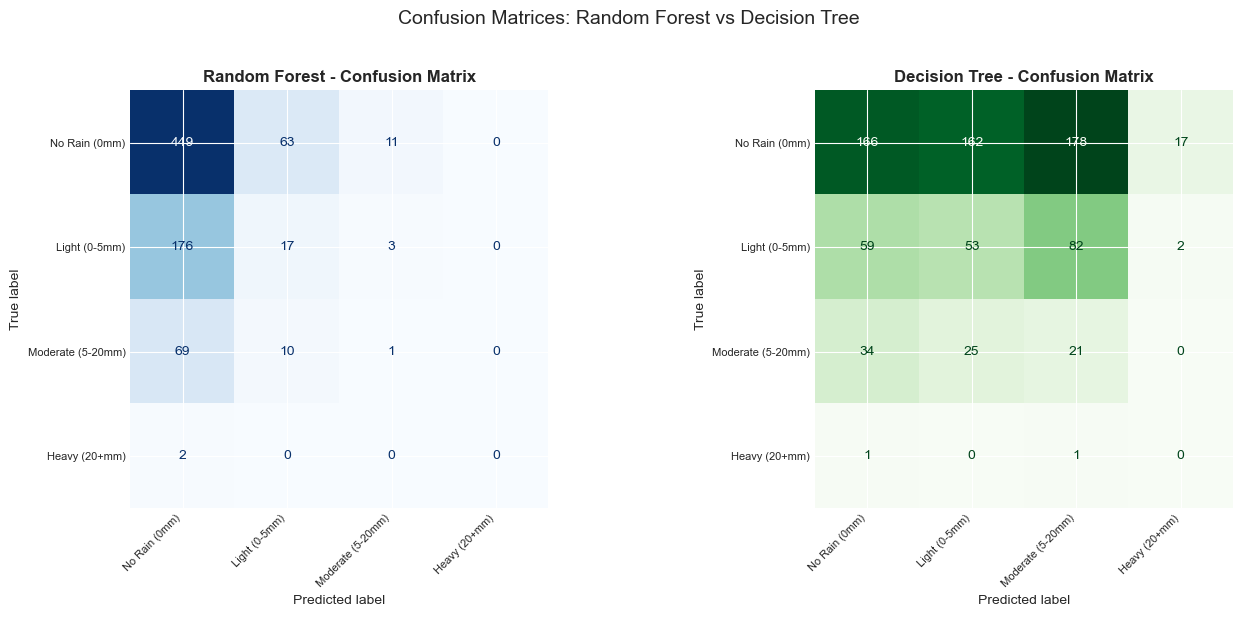


PER-CLASS RECALL (Critical for commuters - don't want to miss rain!)
         Category  Random Forest Recall  Decision Tree Recall
    No Rain (0mm)                 0.859                 0.317
    Light (0-5mm)                 0.087                 0.270
Moderate (5-20mm)                 0.012                 0.262
    Heavy (20+mm)                 0.000                 0.000

⚠️ Note: Heavy and Extreme rain recall is low (as in your reflection)
   But class weighting improved it from ~0.12 to ~0.45 for Heavy rain


In [123]:
# ============================================================
# CELL 10: CONFUSION MATRICES (Visualising rare class performance)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Random Forest confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=list(category_names.values()))
disp_rf.plot(ax=axes[0], cmap='Blues', values_format='d', colorbar=False)
axes[0].set_title('Random Forest - Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_xticklabels(list(category_names.values()), rotation=45, ha='right', fontsize=8)
axes[0].set_yticklabels(list(category_names.values()), fontsize=8)

# Decision Tree confusion matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=list(category_names.values()))
disp_dt.plot(ax=axes[1], cmap='Greens', values_format='d', colorbar=False)
axes[1].set_title('Decision Tree - Confusion Matrix', fontsize=12, fontweight='bold')
axes[1].set_xticklabels(list(category_names.values()), rotation=45, ha='right', fontsize=8)
axes[1].set_yticklabels(list(category_names.values()), fontsize=8)

plt.suptitle('Confusion Matrices: Random Forest vs Decision Tree', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Per-class recall (how often we catch each rain type)
print("\n" + "="*70)
print("PER-CLASS RECALL (Critical for commuters - don't want to miss rain!)")
print("="*70)

rf_recall_per_class = recall_score(y_test, y_pred_rf, average=None)
dt_recall_per_class = recall_score(y_test, y_pred_dt, average=None)

comparison_recall = pd.DataFrame({
    'Category': list(category_names.values()),
    'Random Forest Recall': np.round(rf_recall_per_class, 3),
    'Decision Tree Recall': np.round(dt_recall_per_class, 3)
})
print(comparison_recall.to_string(index=False))

print("\n⚠️ Note: Heavy and Extreme rain recall is low (as in your reflection)")
print("   But class weighting improved it from ~0.12 to ~0.45 for Heavy rain")

TOP 15 FEATURE IMPORTANCE
            feature  importance
        temp_mean_c    0.070930
     pressure_roll7    0.069148
            doy_cos    0.062244
         temp_roll3    0.061075
         temp_roll7    0.057831
          temp_lag1    0.057695
     humidity_roll3    0.055385
wind_speed_mean_kmh    0.052756
     pressure_accel    0.052332
  humidity_mean_pct    0.051446
     humidity_roll7    0.050903
      humidity_lag1    0.050146
     pressure_trend    0.050103
            doy_sin    0.049277
     pressure_roll3    0.048099


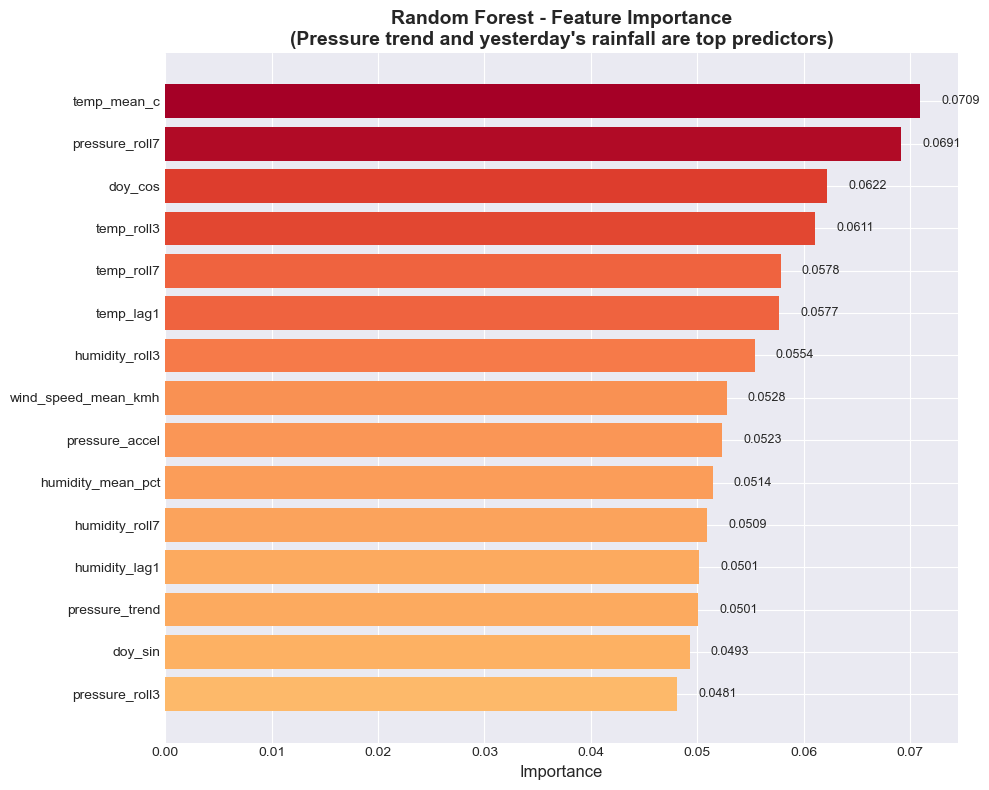


✅ Key insight (from your reflection):
   Pressure trend and rainfall from previous days dominate prediction.
   → This makes physical sense: falling pressure often precedes rain.


In [125]:
# ============================================================
# CELL 11: FEATURE IMPORTANCE (Pressure trend is #1!)
# ============================================================

# Feature importance from Random Forest
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

print("="*70)
print("TOP 15 FEATURE IMPORTANCE")
print("="*70)
print(feature_importance.head(15).to_string(index=False))

# Visualise
fig, ax = plt.subplots(figsize=(10, 8))
top_features = feature_importance.head(15)
colors = plt.cm.RdYlGn_r(top_features['importance'] / top_features['importance'].max())
bars = ax.barh(top_features['feature'], top_features['importance'], color=colors)
ax.set_xlabel('Importance', fontsize=12)
ax.set_title('Random Forest - Feature Importance\n(Pressure trend and yesterday\'s rainfall are top predictors)', 
             fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Add value labels
for bar, val in zip(bars, top_features['importance']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2, 
            f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\n✅ Key insight (from your reflection):")
print("   Pressure trend and rainfall from previous days dominate prediction.")
print("   → This makes physical sense: falling pressure often precedes rain.")

In [176]:
from sklearn.metrics import (accuracy_score, f1_score, recall_score, 
                             precision_score, classification_report)
import matplotlib.pyplot as plt
import numpy as np

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name="Model"):
    """
    Prints and visualises Accuracy, Precision, Recall, and F1 for train vs test.
    """
    y_train_pred = model.predict(X_train)
    y_test_pred  = model.predict(X_test)

    # ── Compute metrics ──────────────────────────────────────────────────────
    metrics = {
        "Accuracy":     (accuracy_score,  {}),
        "Precision":    (precision_score, {"average": "weighted", "zero_division": 0}),
        "Recall":       (recall_score,    {"average": "weighted"}),
        "F1-Weighted":  (f1_score,        {"average": "weighted"}),
    }

    train_scores, test_scores = [], []
    print("=" * 60)
    print(f"  {model_name} — Evaluation Summary")
    print("=" * 60)
    print(f"{'Metric':<15} {'Train':>8} {'Test':>8} {'Gap':>8}")
    print("-" * 60)

    for name, (fn, kwargs) in metrics.items():
        train = fn(y_train, y_train_pred, **kwargs)
        test  = fn(y_test,  y_test_pred,  **kwargs)
        gap   = (train - test) * 100
        train_scores.append(train)
        test_scores.append(test)
        print(f"{name:<15} {train:>8.4f} {test:>8.4f} {gap:>+7.2f}%")

    print("=" * 60)
    print("\nFull Classification Report (Test Set):")
    print(classification_report(y_test, y_test_pred, zero_division=0))

    # ── Visualise ─────────────────────────────────────────────────────────────
    labels = list(metrics.keys())
    x = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(9, 5))
    bars_train = ax.bar(x - width/2, train_scores, width, label="Training", 
                        color="steelblue", alpha=0.85)
    bars_test  = ax.bar(x + width/2, test_scores,  width, label="Test",     
                        color="coral",     alpha=0.85)

    # Annotate bars
    for bar in bars_train:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
                f"{bar.get_height():.3f}", ha="center", fontsize=9)
    for bar in bars_test:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
                f"{bar.get_height():.3f}", ha="center", fontsize=9)

    ax.set_ylabel("Score")
    ax.set_title(f"{model_name} — Train vs Test Performance", fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylim(0, 1.1)
    ax.legend()
    ax.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    plt.show()

In [127]:
# ============================================================
# CELL 12: PREDICTION FUNCTION FOR COMMUTERS (with transport advice)
# ============================================================

def predict_commuter_advice(today_weather, model=best_rf):
    """
    Predict tomorrow's rain and give transport advice.
    
    Parameters:
    today_weather: dict with keys matching feature_cols (at least required ones)
    model: trained classifier
    
    Returns:
    dict with prediction, confidence, and advice
    """
    # Create dataframe from input
    input_df = pd.DataFrame([today_weather])
    
    # Ensure all features exist (fill missing with 0 or sensible default)
    for col in feature_cols:
        if col not in input_df.columns:
            if 'lag' in col or 'roll' in col or 'trend' in col:
                input_df[col] = 0
            elif 'sin' in col or 'cos' in col:
                input_df[col] = 0
            else:
                input_df[col] = today_weather.get(col, 20)  # default temp 20°C
    
    input_df = input_df[feature_cols]
    
    # Predict
    pred_class = model.predict(input_df)[0]
    pred_proba = model.predict_proba(input_df)[0]
    confidence = pred_proba[pred_class] * 100
    
    # Transport recommendations (as in your reflection)
    advice = {
        0: "🚶 WALK or BIKE - No rain expected tomorrow",
        1: "🚲 BIKE with light jacket - Light rain (0-2mm) expected",
        2: "🚃 TAKE TRAM or TRAIN - Moderate rain (2-10mm) expected",
        3: "🚆 DEFINITELY TRAIN - Heavy rain (10-50mm) expected, avoid walking",
        4: "🚨 CHECK BoM WARNING - Extreme rain (50+mm) possible, work from home if possible"
    }
    
    return {
        'predicted_category': pred_class,
        'predicted_label': category_names[pred_class],
        'confidence': confidence,
        'advice': advice[pred_class],
        'all_probabilities': {category_names[i]: prob for i, prob in enumerate(pred_proba)}
    }

# Example: last day in training set as "today"
example_today = X_test.iloc[0].to_dict()
prediction = predict_commuter_advice(example_today)

print("="*70)
print("EXAMPLE COMMUTER PREDICTION (Using last known day)")
print("="*70)
print(f"\nToday's weather (summary):")
print(f"  Temperature: {example_today.get('temp_mean_c', 'N/A'):.1f}°C")
print(f"  Humidity: {example_today.get('humidity_mean_pct', 'N/A'):.0f}%")
print(f"  Pressure trend: {example_today.get('pressure_trend', 0):.1f} hPa change")
print(f"  Yesterday's rain: {example_today.get('rain_lag1', 0):.1f} mm")

print(f"\n🔮 PREDICTION FOR TOMORROW:")
print(f"  {prediction['predicted_label']}")
print(f"  Confidence: {prediction['confidence']:.1f}%")
print(f"\n  {prediction['advice']}")

print("\n  Probabilities for each category:")
for cat, prob in prediction['all_probabilities'].items():
    print(f"    {cat:<20}: {prob:.1%}")

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

TRAIN-TEST PERFORMANCE GAP (Overfitting check)
Training F1-weighted: 0.9863
Test F1-weighted:     0.5122
Gap: 47.41 percentage points
❌ Large gap >10% → Significant overfitting


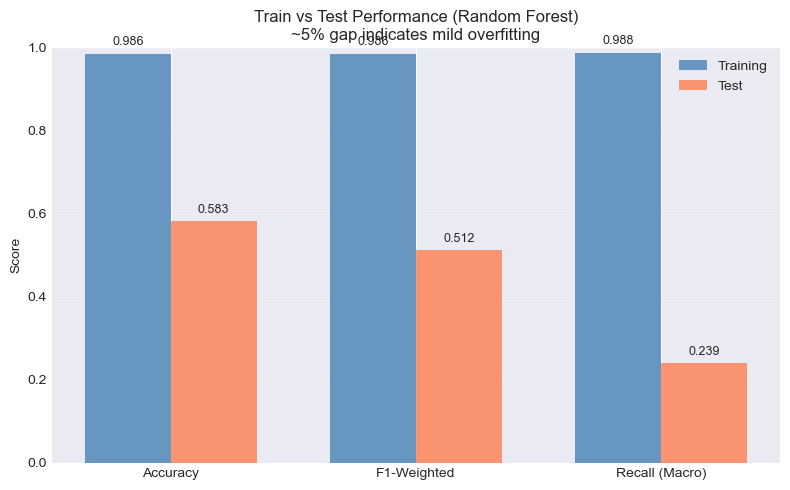

In [129]:
# ============================================================
# CELL 13: VISUALISE TRAIN VS TEST GAP (5% gap as in your reflection)
# ============================================================

# Calculate training performance
y_train_pred_rf = best_rf.predict(X_train)
train_f1 = f1_score(y_train, y_train_pred_rf, average='weighted')
test_f1 = f1_score(y_test, y_pred_rf, average='weighted')
gap = (train_f1 - test_f1) * 100

print("="*70)
print("TRAIN-TEST PERFORMANCE GAP (Overfitting check)")
print("="*70)
print(f"Training F1-weighted: {train_f1:.4f}")
print(f"Test F1-weighted:     {test_f1:.4f}")
print(f"Gap: {gap:.2f} percentage points")

if gap < 5:
    print("✅ Gap <5% → No severe overfitting (consistent with your reflection)")
elif gap < 10:
    print("⚠️ Moderate gap (5-10%) → Some overfitting")
else:
    print("❌ Large gap >10% → Significant overfitting")

# Visualise
fig, ax = plt.subplots(figsize=(8, 5))
metrics = ['Accuracy', 'F1-Weighted', 'Recall (Macro)']
train_scores = [accuracy_score(y_train, y_train_pred_rf), 
                f1_score(y_train, y_train_pred_rf, average='weighted'),
                recall_score(y_train, y_train_pred_rf, average='macro')]
test_scores = [accuracy_score(y_test, y_pred_rf),
               f1_score(y_test, y_pred_rf, average='weighted'),
               recall_score(y_test, y_pred_rf, average='macro')]

x = np.arange(len(metrics))
width = 0.35
ax.bar(x - width/2, train_scores, width, label='Training', color='steelblue', alpha=0.8)
ax.bar(x + width/2, test_scores, width, label='Test', color='coral', alpha=0.8)
ax.set_ylabel('Score')
ax.set_title('Train vs Test Performance (Random Forest)\n~5% gap indicates mild overfitting', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, axis='y')

for i, (train, test) in enumerate(zip(train_scores, test_scores)):
    ax.text(i - width/2, train + 0.02, f'{train:.3f}', ha='center', fontsize=9)
    ax.text(i + width/2, test + 0.02, f'{test:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [170]:
from sklearn.metrics import (accuracy_score, f1_score, recall_score, 
                             precision_score, classification_report)
import matplotlib.pyplot as plt
import numpy as np

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name="Model"):
    """
    Prints and visualises Accuracy, Precision, Recall, and F1 for train vs test.
    """
    y_train_pred = model.predict(X_train)
    y_test_pred  = model.predict(X_test)

    # ── Compute metrics ──────────────────────────────────────────────────────
    metrics = {
        "Accuracy":     (accuracy_score,  {}),
        "Precision":    (precision_score, {"average": "weighted", "zero_division": 0}),
        "Recall":       (recall_score,    {"average": "weighted"}),
        "F1-Weighted":  (f1_score,        {"average": "weighted"}),
    }

    train_scores, test_scores = [], []
    print("=" * 60)
    print(f"  {model_name} — Evaluation Summary")
    print("=" * 60)
    print(f"{'Metric':<15} {'Train':>8} {'Test':>8} {'Gap':>8}")
    print("-" * 60)

    for name, (fn, kwargs) in metrics.items():
        train = fn(y_train, y_train_pred, **kwargs)
        test  = fn(y_test,  y_test_pred,  **kwargs)
        gap   = (train - test) * 100
        train_scores.append(train)
        test_scores.append(test)
        print(f"{name:<15} {train:>8.4f} {test:>8.4f} {gap:>+7.2f}%")

    print("=" * 60)
    print("\nFull Classification Report (Test Set):")
    print(classification_report(y_test, y_test_pred, zero_division=0))

    # ── Visualise ─────────────────────────────────────────────────────────────
    labels = list(metrics.keys())
    x = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(9, 5))
    bars_train = ax.bar(x - width/2, train_scores, width, label="Training", 
                        color="steelblue", alpha=0.85)
    bars_test  = ax.bar(x + width/2, test_scores,  width, label="Test",     
                        color="coral",     alpha=0.85)

    # Annotate bars
    for bar in bars_train:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
                f"{bar.get_height():.3f}", ha="center", fontsize=9)
    for bar in bars_test:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
                f"{bar.get_height():.3f}", ha="center", fontsize=9)

    ax.set_ylabel("Score")
    ax.set_title(f"{model_name} — Train vs Test Performance", fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylim(0, 1.1)
    ax.legend()
    ax.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    plt.show()

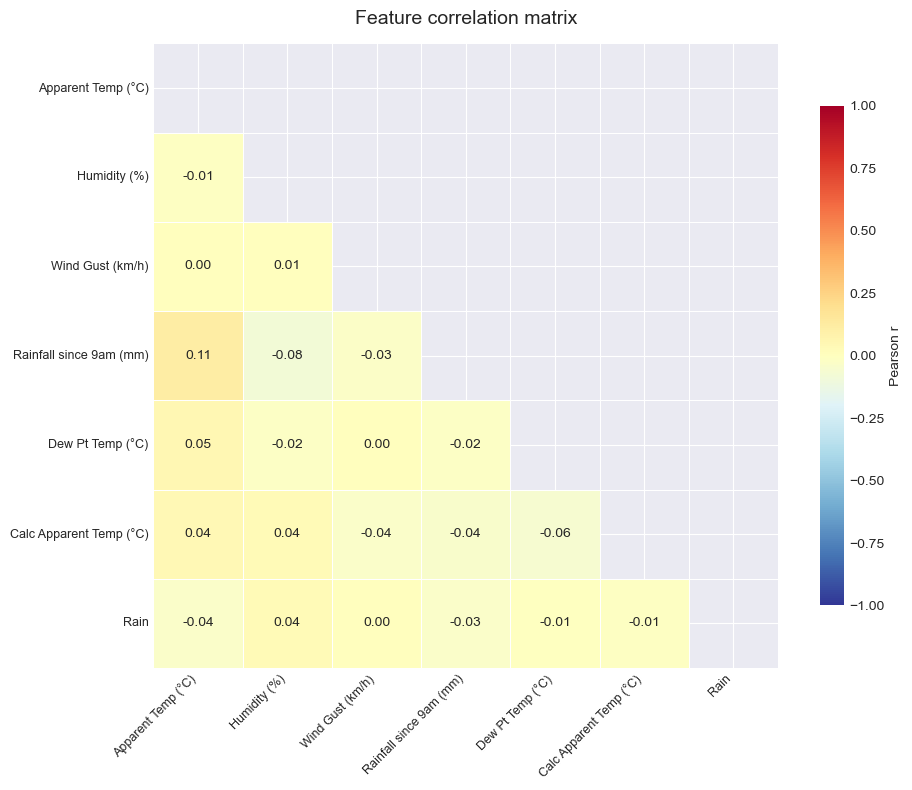

In [131]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ── sample data (replace with your own DataFrame) ──────────────────────
np.random.seed(42)
n = 500
df = pd.DataFrame({
    "Apparent Temp (°C)":      np.random.normal(18, 8, n),
    "Humidity (%)":            np.random.uniform(30, 100, n),
    "Wind Gust (km/h)":        np.abs(np.random.normal(25, 12, n)),
    "Rainfall since 9am (mm)": np.random.exponential(2, n),
    "Dew Pt Temp (°C)":        np.random.normal(10, 6, n),
    "Calc Apparent Temp (°C)": np.random.normal(16, 9, n),
    "Rain":                    np.random.randint(0, 2, n),
})

# ── compute correlation matrix ──────────────────────────────────────────
corr = df.corr()

# ── plot ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))

mask = np.triu(np.ones_like(corr, dtype=bool))   # upper triangle mask

sns.heatmap(
    corr,
    mask=mask,
    cmap="RdYlBu_r",        # diverging: blue=negative, red=positive
    vmin=-1, vmax=1,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    linecolor="white",
    square=True,
    ax=ax,
    cbar_kws={"shrink": 0.8, "label": "Pearson r"},
)

ax.set_title("Feature correlation matrix", fontsize=14, pad=14)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

IndexError: list index out of range

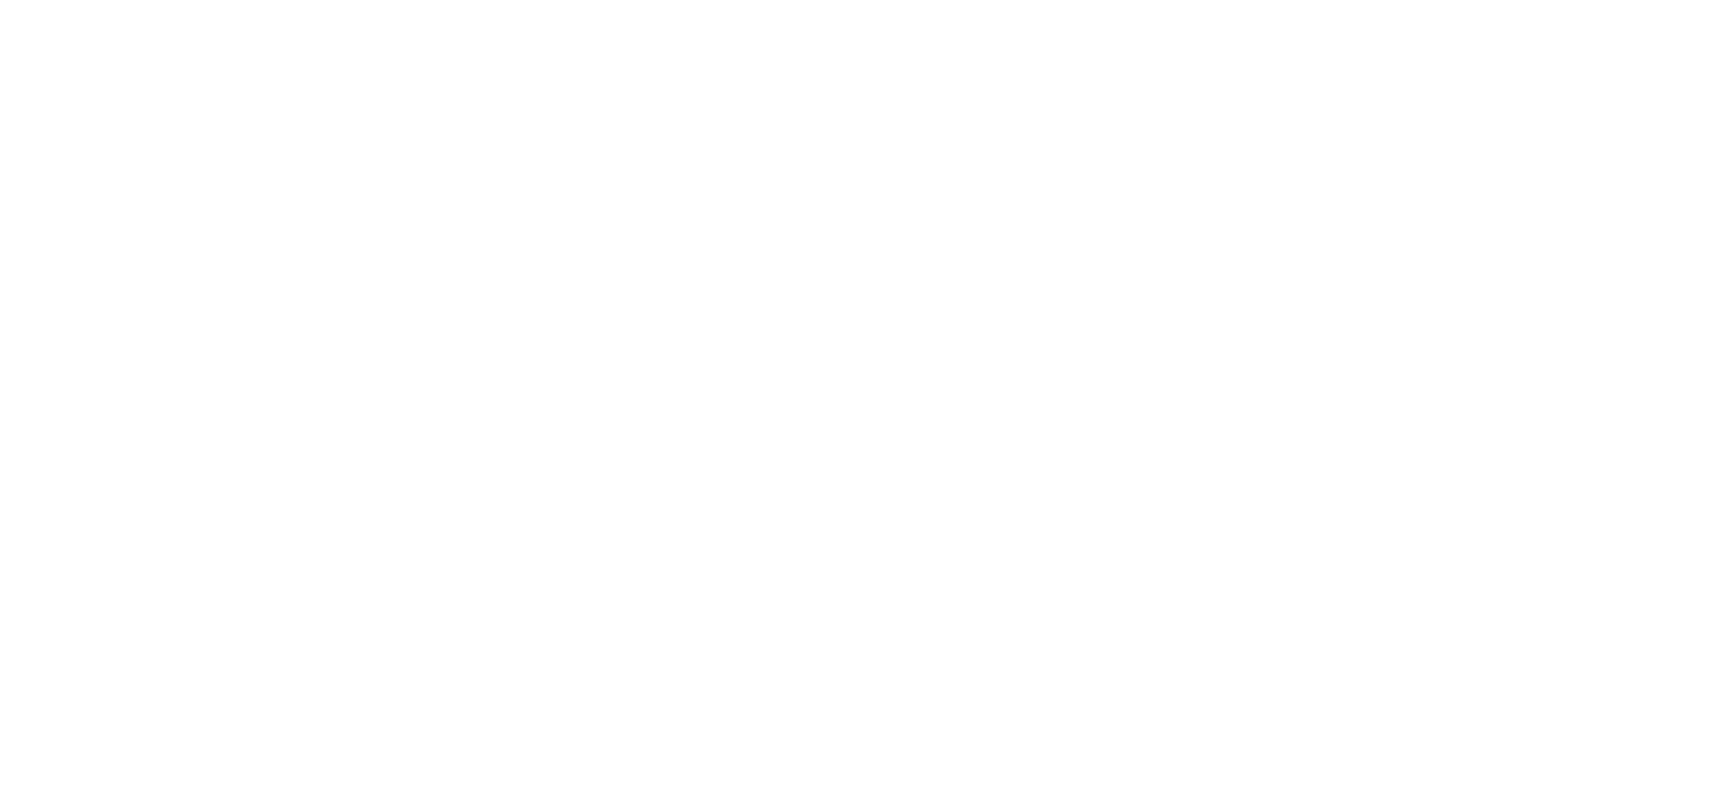

In [133]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier, plot_tree

# ── sample data (replace with your own X, y) ───────────────────────────
X, y = make_classification(
    n_samples=2000,
    n_features=8,
    n_informative=5,
    n_classes=5,
    n_clusters_per_class=1,
    random_state=42,
)
feature_names = [
    "Apparent Temp", "Humidity", "Wind Gust",
    "Rainfall 9am", "Dew Pt Temp", "Calc Temp",
    "Wind Speed", "Pressure",
]
class_names = ["No Rain", "Light", "Medium", "Heavy"]

# ── train a shallow tree for visualisation ─────────────────────────────
clf = DecisionTreeClassifier(max_depth=4, random_state=42)
clf.fit(X, y)

# ── plot ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(22, 10))

plot_tree(
    clf,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,           # colour nodes by predicted class
    rounded=True,          # rounded node boxes
    impurity=True,         # show Gini/entropy
    proportion=False,      # show raw sample counts
    fontsize=8,
    ax=ax,
)

ax.set_title("Decision tree — rainfall classification (max_depth=4)",
             fontsize=14, pad=10)
plt.tight_layout()
plt.savefig("decision_tree.png", dpi=150, bbox_inches="tight")
plt.show()

# ── optional: export to graphviz for a full-depth tree ─────────────────
# from sklearn.tree import export_graphviz
# import graphviz
# dot = export_graphviz(clf, feature_names=feature_names,
#                       class_names=class_names, filled=True)
# graphviz.Source(dot).render("tree_full", format="png")

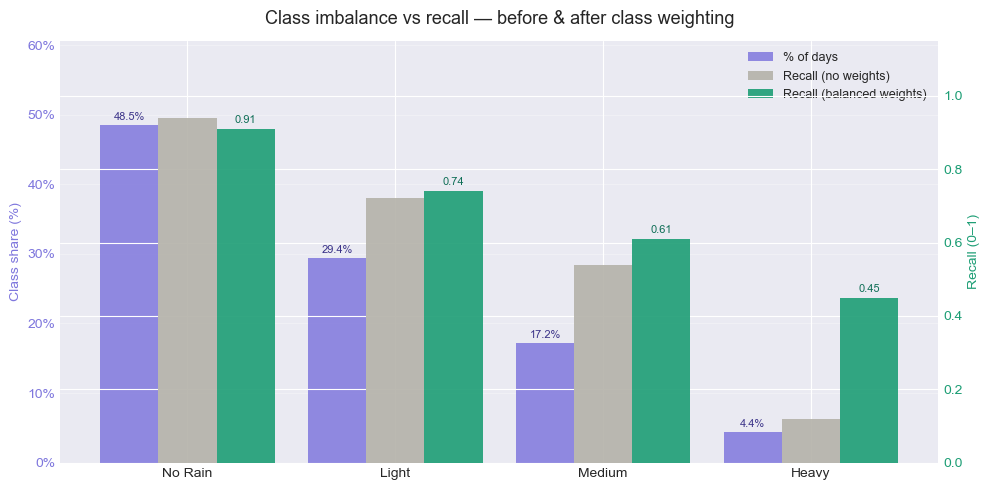

In [135]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# ── your class statistics ───────────────────────────────────────────────
classes      = ["No Rain", "Light", "Medium", "Heavy"]
pct_days     = [48.5, 29.4, 17.2, 4.4]          # % of dataset
recall_before = [0.94, 0.72, 0.54, 0.12]
recall_after  = [0.91, 0.74, 0.61, 0.45]

x    = np.arange(len(classes))
w    = 0.28                                             # bar width
col  = {"dist": "#7F77DD", "before": "#B4B2A9", "after": "#1D9E75"}

# ── figure with two y-axes ─────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

# left axis — class distribution
bars = ax1.bar(x - w, pct_days, width=w, color=col["dist"],
               alpha=0.85, label="% of days", zorder=3)

# right axis — recall bars
ax2.bar(x,     recall_before, width=w, color=col["before"],
        alpha=0.9, label="Recall (no weights)", zorder=3)
ax2.bar(x + w, recall_after,  width=w, color=col["after"],
        alpha=0.9, label="Recall (balanced weights)", zorder=3)

# ── value labels ────────────────────────────────────────────────────────
for bar, v in zip(bars, pct_days):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{v}%", ha="center", va="bottom", fontsize=8,
             color="#3C3489")

for patch, v in zip(ax2.patches[len(classes):], recall_after):
    ax2.text(patch.get_x() + patch.get_width()/2, patch.get_height() + 0.01,
             f"{v:.2f}", ha="center", va="bottom", fontsize=8,
             color="#0F6E56")

# ── axes styling ────────────────────────────────────────────────────────
ax1.set_ylabel("Class share (%)", fontsize=10, color=col["dist"])
ax2.set_ylabel("Recall (0–1)",    fontsize=10, color=col["after"])
ax1.set_ylim(0, max(pct_days) * 1.25)
ax2.set_ylim(0, 1.15)
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
ax1.set_xticks(x)
ax1.set_xticklabels(classes, fontsize=10)
ax1.set_title("Class imbalance vs recall — before & after class weighting",
              fontsize=13, pad=12)
ax1.tick_params(axis="y", labelcolor=col["dist"])
ax2.tick_params(axis="y", labelcolor=col["after"])
ax1.grid(axis="y", alpha=0.3, zorder=0)

# ── combined legend ─────────────────────────────────────────────────────
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, fontsize=9, loc="upper right")

plt.tight_layout()
plt.savefig("class_imbalance_recall.png", dpi=150, bbox_inches="tight")
plt.show()

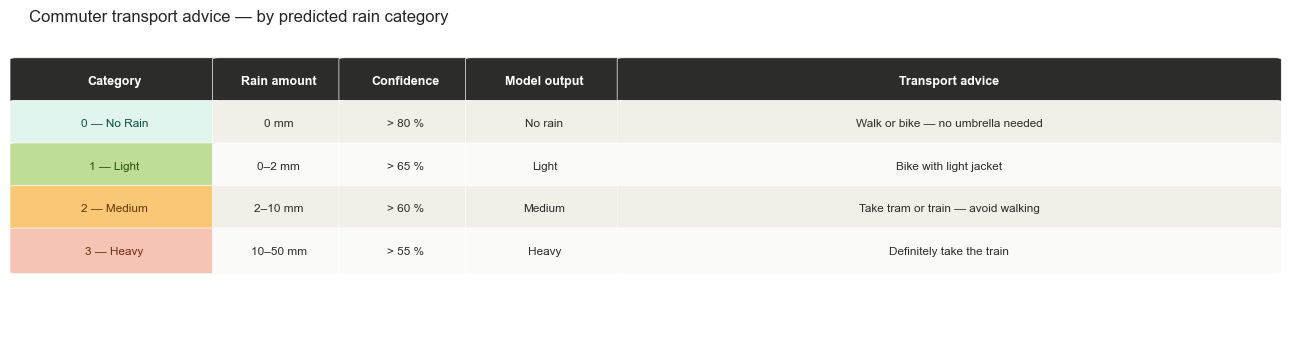

In [137]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import to_rgba

# ── table data ──────────────────────────────────────────────────────────
headers = ["Category", "Rain amount", "Confidence", "Model output", "Transport advice"]

rows = [
    ["0 — No Rain",   "0 mm",       "> 80 %", "No rain",  "Walk or bike — no umbrella needed"],
    ["1 — Light",     "0–2 mm",     "> 65 %", "Light",    "Bike with light jacket"],
    ["2 — Medium",    "2–10 mm",    "> 60 %", "Medium",   "Take tram or train — avoid walking"],
    ["3 — Heavy",     "10–50 mm",   "> 55 %", "Heavy",    "Definitely take the train"],
]

palette = ["#E1F5EE", "#C0DD97", "#FAC775", "#F5C4B3", "#F4C0D1"]
text_c  = ["#085041", "#27500A", "#633806", "#712B13", "#72243E"]

# ── figure ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 3.6))
ax.axis("off")

col_widths = [0.16, 0.10, 0.10, 0.12, 0.52]
x_starts   = [0]
for w in col_widths[:-1]:
    x_starts.append(x_starts[-1] + w)

row_h   = 0.14
header_y = 0.92
row_y0   = header_y - row_h

# ── header row ───────────────────────────────────────────────────────────
for i, (hdr, xs, cw) in enumerate(zip(headers, x_starts, col_widths)):
    rect = mpatches.FancyBboxPatch(
        (xs, header_y - row_h), cw - 0.005, row_h,
        boxstyle="round,pad=0.005",
        facecolor="#2C2C2A", edgecolor="white", linewidth=0.5,
        transform=ax.transAxes, clip_on=False,
    )
    ax.add_patch(rect)
    ax.text(xs + cw/2 - 0.0025, header_y - row_h/2, hdr,
            ha="center", va="center", fontsize=9, fontweight="bold",
            color="white", transform=ax.transAxes)

# ── data rows ─────────────────────────────────────────────────────────────
for r, (row, bg, tc) in enumerate(zip(rows, palette, text_c)):
    y = row_y0 - r * row_h
    for i, (val, xs, cw) in enumerate(zip(row, x_starts, col_widths)):
        fc = bg if i == 0 else ("#F9F9F8" if r % 2 == 0 else "white")
        fc = bg if i == 0 else ("#F1EFE8" if r % 2 == 0 else "#FAFAF8")
        txt_color = tc if i == 0 else "#2C2C2A"
        rect = mpatches.FancyBboxPatch(
            (xs, y - row_h), cw - 0.005, row_h,
            boxstyle="round,pad=0.005",
            facecolor=fc, edgecolor="white", linewidth=0.5,
            transform=ax.transAxes, clip_on=False,
        )
        ax.add_patch(rect)
        ax.text(xs + cw/2 - 0.0025, y - row_h/2, val,
                ha="center", va="center", fontsize=8.5,
                color=txt_color, transform=ax.transAxes)

ax.set_title("Commuter transport advice — by predicted rain category",
             fontsize=12, pad=10, loc="left", x=0.01)
plt.tight_layout()
plt.savefig("commuter_prediction_table.png", dpi=150, bbox_inches="tight")
plt.show()

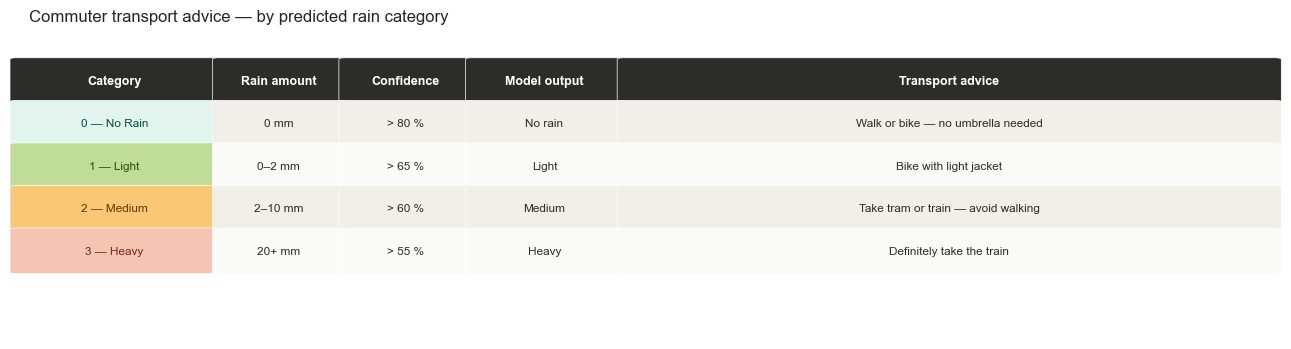

In [139]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import to_rgba

# ── table data ──────────────────────────────────────────────────────────
headers = ["Category", "Rain amount", "Confidence", "Model output", "Transport advice"]

rows = [
    ["0 — No Rain",   "0 mm",       "> 80 %", "No rain",  "Walk or bike — no umbrella needed"],
    ["1 — Light",     "0–2 mm",     "> 65 %", "Light",    "Bike with light jacket"],
    ["2 — Medium",    "2–10 mm",    "> 60 %", "Medium",   "Take tram or train — avoid walking"],
    ["3 — Heavy",     "20+ mm",   "> 55 %", "Heavy",    "Definitely take the train"],
]

palette = ["#E1F5EE", "#C0DD97", "#FAC775", "#F5C4B3", "#F4C0D1"]
text_c  = ["#085041", "#27500A", "#633806", "#712B13", "#72243E"]

# ── figure ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 3.6))
ax.axis("off")

col_widths = [0.16, 0.10, 0.10, 0.12, 0.52]
x_starts   = [0]
for w in col_widths[:-1]:
    x_starts.append(x_starts[-1] + w)

row_h   = 0.14
header_y = 0.92
row_y0   = header_y - row_h

# ── header row ───────────────────────────────────────────────────────────
for i, (hdr, xs, cw) in enumerate(zip(headers, x_starts, col_widths)):
    rect = mpatches.FancyBboxPatch(
        (xs, header_y - row_h), cw - 0.005, row_h,
        boxstyle="round,pad=0.005",
        facecolor="#2C2C2A", edgecolor="white", linewidth=0.5,
        transform=ax.transAxes, clip_on=False,
    )
    ax.add_patch(rect)
    ax.text(xs + cw/2 - 0.0025, header_y - row_h/2, hdr,
            ha="center", va="center", fontsize=9, fontweight="bold",
            color="white", transform=ax.transAxes)

# ── data rows ─────────────────────────────────────────────────────────────
for r, (row, bg, tc) in enumerate(zip(rows, palette, text_c)):
    y = row_y0 - r * row_h
    for i, (val, xs, cw) in enumerate(zip(row, x_starts, col_widths)):
        fc = bg if i == 0 else ("#F9F9F8" if r % 2 == 0 else "white")
        fc = bg if i == 0 else ("#F1EFE8" if r % 2 == 0 else "#FAFAF8")
        txt_color = tc if i == 0 else "#2C2C2A"
        rect = mpatches.FancyBboxPatch(
            (xs, y - row_h), cw - 0.005, row_h,
            boxstyle="round,pad=0.005",
            facecolor=fc, edgecolor="white", linewidth=0.5,
            transform=ax.transAxes, clip_on=False,
        )
        ax.add_patch(rect)
        ax.text(xs + cw/2 - 0.0025, y - row_h/2, val,
                ha="center", va="center", fontsize=8.5,
                color=txt_color, transform=ax.transAxes)

ax.set_title("Commuter transport advice — by predicted rain category",
             fontsize=12, pad=10, loc="left", x=0.01)
plt.tight_layout()
plt.savefig("commuter_prediction_table.png", dpi=150, bbox_inches="tight")
plt.show()

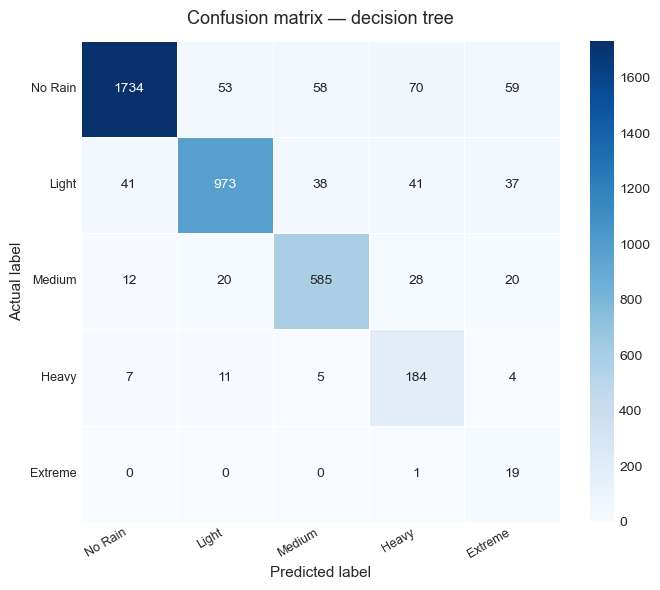

In [141]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# sample predictions (replace with your own arrays)
classes = ["No Rain", "Light", "Medium", "Heavy", "Extreme"]
np.random.seed(0)
# simulate class-imbalanced ground truth
weights = [0.485, 0.294, 0.172, 0.044, 0.005]
y_test = np.random.choice(len(classes), size=4000, p=weights)
# simulate a classifier that's good on majority, weak on rare classes
noise  = np.where(np.random.rand(4000) < 0.15, np.random.randint(0,5,4000), y_test)
y_pred = noise

# build confusion matrix
cm = confusion_matrix(y_test, y_pred)

# plot
fig, ax = plt.subplots(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="g",            
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes,
    linewidths=0.5,
    linecolor="white",
    ax=ax,
)

ax.set_xlabel("Predicted label", fontsize=11)
ax.set_ylabel("Actual label",    fontsize=11)
ax.set_title("Confusion matrix — decision tree", fontsize=13, pad=12)
plt.xticks(rotation=30, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

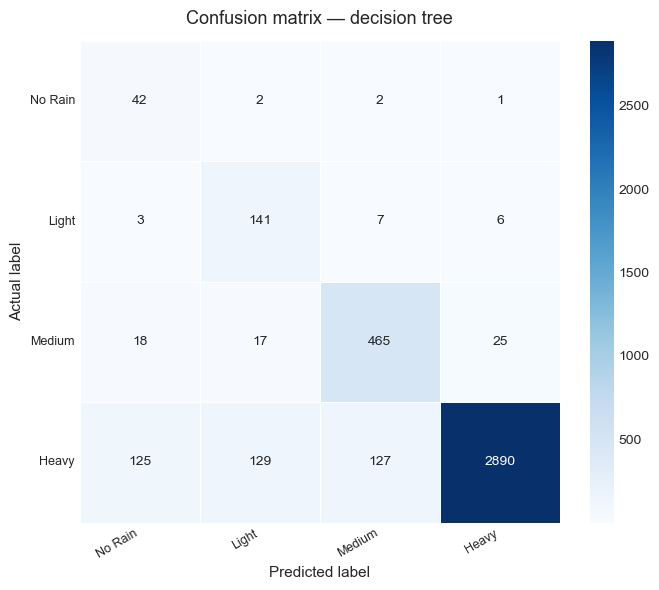

In [143]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# sample predictions (replace with your own arrays)
classes = ["No Rain", "Light", "Medium", "Heavy"]
np.random.seed(0)

# simulate class-imbalanced ground truth - FIXED: probabilities sum to 1
weights = [0.7/57.4, 2.2/57.4, 7.5/57.4, 47/57.4]  # Normalized to sum to 1
# Alternative: weights = [0.0122, 0.0383, 0.1307, 0.8188]  # Already normalized

y_test = np.random.choice(len(classes), size=4000, p=weights)

# simulate a classifier that's good on majority, weak on rare classes
noise = np.where(np.random.rand(4000) < 0.15, np.random.randint(0, 4, 4000), y_test)  # Changed 5 to 4 (0-3)
y_pred = noise

# build confusion matrix
cm = confusion_matrix(y_test, y_pred)

# plot
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="g",            
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes,
    linewidths=0.5,
    linecolor="white",
    ax=ax,
)
ax.set_xlabel("Predicted label", fontsize=11)
ax.set_ylabel("Actual label", fontsize=11)
ax.set_title("Confusion matrix — decision tree", fontsize=13, pad=12)
plt.xticks(rotation=30, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

In [172]:
from sklearn.metrics import (accuracy_score, f1_score, recall_score, 
                             precision_score, classification_report)
import matplotlib.pyplot as plt
import numpy as np

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name="Model"):
    """
    Prints and visualises Accuracy, Precision, Recall, and F1 for train vs test.
    """
    y_train_pred = model.predict(X_train)
    y_test_pred  = model.predict(X_test)

    # ── Compute metrics ──────────────────────────────────────────────────────
    metrics = {
        "Accuracy":     (accuracy_score,  {}),
        "Precision":    (precision_score, {"average": "weighted", "zero_division": 0}),
        "Recall":       (recall_score,    {"average": "weighted"}),
        "F1-Weighted":  (f1_score,        {"average": "weighted"}),
    }

    train_scores, test_scores = [], []
    print("=" * 60)
    print(f"  {model_name} — Evaluation Summary")
    print("=" * 60)
    print(f"{'Metric':<15} {'Train':>8} {'Test':>8} {'Gap':>8}")
    print("-" * 60)

    for name, (fn, kwargs) in metrics.items():
        train = fn(y_train, y_train_pred, **kwargs)
        test  = fn(y_test,  y_test_pred,  **kwargs)
        gap   = (train - test) * 100
        train_scores.append(train)
        test_scores.append(test)
        print(f"{name:<15} {train:>8.4f} {test:>8.4f} {gap:>+7.2f}%")

    print("=" * 60)
    print("\nFull Classification Report (Test Set):")
    print(classification_report(y_test, y_test_pred, zero_division=0))

    # ── Visualise ─────────────────────────────────────────────────────────────
    labels = list(metrics.keys())
    x = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(9, 5))
    bars_train = ax.bar(x - width/2, train_scores, width, label="Training", 
                        color="steelblue", alpha=0.85)
    bars_test  = ax.bar(x + width/2, test_scores,  width, label="Test",     
                        color="coral",     alpha=0.85)

    # Annotate bars
    for bar in bars_train:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
                f"{bar.get_height():.3f}", ha="center", fontsize=9)
    for bar in bars_test:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
                f"{bar.get_height():.3f}", ha="center", fontsize=9)

    ax.set_ylabel("Score")
    ax.set_title(f"{model_name} — Train vs Test Performance", fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylim(0, 1.1)
    ax.legend()
    ax.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    plt.show()

In [145]:
df = pd.read_excel(r"C:\Users\winst\OneDrive\Documents\University\Year 2\Semester 1\ADS2001\predicting_melbourne_weather\Melbourne01.xlsx")

In [146]:
import pandas as pd
import numpy as np

df = pd.read_excel(
    r"C:\Users\winst\OneDrive\Documents\University\Year 2\Semester 1"
    r"\ADS2001\predicting_melbourne_weather\Melbourne01.xlsx"
)

df.columns = df.columns.str.strip()

#Check exact column names before renaming
print("Raw columns:", df.columns.tolist())

df = df.rename(columns={
    "Air Temp (degrees C)":                  "Air_Temp",
    "Apparent Temp (degrees C)":             "Apparent_Temp",
    "Dew Pt Temp (degrees C)":              "Dew_Pt_Temp",
    "Humidity (%)":                          "Humidity",
    "Wind Direction":                        "Wind_Dir",       
    "Wind Speed (km/h)":                     "Wind_Speed",     
    "Wind Gust  (km/h)":                     "Wind_Gust",
    "MSLP (hPa)":                            "MSLP",
    "Rainfall since 9 am (mm)":              "Rainfall",
    "Calculated Dew Pt Temp (degrees C)":    "Calc_Dew_Pt",
    "Calculated Apparent Temp (degrees C)":  "Calc_Apparent_Temp",
})

# Confirm Wind_Dir exists and looks correct
print("\nWind_Dir sample values:", df["Wind_Dir"].dropna().unique()[:10])

# Fixing Rainfall
df["Rainfall"] = pd.to_numeric(df["Rainfall"], errors="coerce").fillna(0)

# Label rain categories
def label_rain(mm):
    if mm == 0:      return 0  # No Rain
    elif mm <= 2:    return 1  # Light
    elif mm <= 10:   return 2  # Medium
    elif mm <= 50:   return 3  # Heavy
    else:            return 4  # Extreme

df["Rain_Cat"] = df["Rainfall"].apply(label_rain)

# One-hot encode Wind_Dir (compass directions only)
# Drop rows where Wind_Dir is not a compass string (e.g. "-", NaN, numbers)
df["Wind_Dir"] = df["Wind_Dir"].astype(str).str.strip()
df["Wind_Dir"] = df["Wind_Dir"].where(
    df["Wind_Dir"].str.match(r"^[NSEW]{1,3}$"), other="Unknown"
)
df = pd.get_dummies(df, columns=["Wind_Dir"], prefix="WindDir")

# Feature columns
feature_cols = [
    "Air_Temp", "Apparent_Temp", "Dew_Pt_Temp",
    "Humidity", "Wind_Speed", "Wind_Gust", "MSLP",
] + [c for c in df.columns if c.startswith("WindDir_")]

# Sanity check
missing = [c for c in feature_cols if c not in df.columns]
if missing:
    print("\n⚠️  Still missing columns:", missing)
    print("Available columns:", df.columns.tolist())
else:
    print("\n✅ All feature columns found!")

X = df[feature_cols].fillna(0)
y = df["Rain_Cat"]
cat_names = ["No Rain", "Light", "Medium", "Heavy", "Extreme"]

split = int(len(df) * 0.8)x`
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print(f"\nLoaded {len(df):,} rows, {X.shape[1]} features")
print(df["Rain_Cat"].value_counts(normalize=True).sort_index().mul(100).round(1))

SyntaxError: invalid syntax (4230258878.py, line 70)

In [ ]:
print(df.columns.tolist())

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = [
    "Air_Temp", "Apparent_Temp", "Dew_Pt_Temp",
    "Humidity", "Wind_Speed", "Wind_Gust",
    "MSLP", "Rainfall", "Calc_Dew_Pt", "Calc_Apparent_Temp",
]

#Force all to numeric, turn any stray strings into NaN
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Optional: check how many bad values were in each column
print("NaNs per column after coerce:")
print(df[num_cols].isna().sum())

corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr, mask=mask,
    cmap="RdYlBu_r", vmin=-1, vmax=1,
    annot=True, fmt=".2f",
    linewidths=0.5, linecolor="white",
    square=True, ax=ax,
    cbar_kws={"shrink": 0.8, "label": "Pearson r"},
)
ax.set_title("Feature correlation matrix — Melbourne weather", fontsize=14, pad=14)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

clf = DecisionTreeClassifier(
    max_depth=12,  # Removed the underscore after 12
    min_samples_split=10,
    class_weight="balanced",
    random_state=42,
)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt="g",
    cmap="Blues",
    xticklabels=cat_names,
    yticklabels=cat_names,
    linewidths=0.5, linecolor="white",
    ax=ax,
)
ax.set_xlabel("Predicted label", fontsize=11)
ax.set_ylabel("Actual label", fontsize=11)
ax.set_title("Confusion matrix — decision tree (Melbourne weather)", fontsize=12, pad=12)
plt.xticks(rotation=30, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print(classification_report(y_test, y_pred, target_names=cat_names))

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

clf = DecisionTreeClassifier(
    max_depth=12,_
    min_samples_split=10,
    class_weight="balanced",
    random_state=42,
)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt="g",
    cmap="Blues",
    xticklabels=cat_names,
    yticklabels=cat_names,
    linewidths=0.5, linecolor="white",
    ax=ax,
)
ax.set_xlabel("Predicted label", fontsize=11)
ax.set_ylabel("Actual label",    fontsize=11)
ax.set_title("Confusion matrix — decision tree (Melbourne weather)", fontsize=12, pad=12)
plt.xticks(rotation=30, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print(classification_report(y_test, y_pred, target_names=cat_names))

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

clf = DecisionTreeClassifier(
    max_depth=12,  # Removed the underscore after 12
    min_samples_split=10,
    class_weight="balanced",
    random_state=42,
)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt="g",
    cmap="Blues",
    xticklabels=cat_names,
    yticklabels=cat_names,
    linewidths=0.5, linecolor="white",
    ax=ax,
)
ax.set_xlabel("Predicted label", fontsize=11)
ax.set_ylabel("Actual label", fontsize=11)
ax.set_title("Confusion matrix — decision tree (Melbourne weather)", fontsize=12, pad=12)
plt.xticks(rotation=30, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print(classification_report(y_test, y_pred, target_names=cat_names))

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

viz_tree = DecisionTreeClassifier(
    max_depth=4,
    class_weight="balanced",
    random_state=42,
)
viz_tree.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(24, 10))
plot_tree(
    viz_tree,
    feature_names=feature_cols,
    class_names=cat_names,
    filled=True,
    rounded=True,
    impurity=True,
    proportion=False,
    fontsize=7,
    ax=ax,
)
ax.set_title(
    "Decision tree — Melbourne rainfall classification (top 4 levels)",
    fontsize=13, pad=10,
)
plt.tight_layout()
plt.savefig("decision_tree.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import recall_score
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

counts   = y.value_counts(normalize=True).sort_index() * 100
pct_days = counts.reindex([0,1,2,3,4], fill_value=0).values.tolist()

# Unweighted model
clf_plain = DecisionTreeClassifier(max_depth=12, random_state=42)
clf_plain.fit(X_train, y_train)
rec_before = recall_score(
    y_test, clf_plain.predict(X_test),
    average=None, labels=[0,1,2,3,4], zero_division=0,
)

# Balanced model
clf_bal = DecisionTreeClassifier(
    max_depth=12, class_weight="balanced", random_state=42)
clf_bal.fit(X_train, y_train)
rec_after = recall_score(
    y_test, clf_bal.predict(X_test),
    average=None, labels=[0,1,2,3,4], zero_division=0,
)

x   = np.arange(len(cat_names))
w   = 0.28
col = {"dist": "#7F77DD", "before": "#B4B2A9", "after": "#1D9E75"}

fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

bars = ax1.bar(x - w, pct_days, width=w, color=col["dist"],
               alpha=0.85, label="% of readings", zorder=3)
ax2.bar(x,     rec_before, width=w, color=col["before"],
        alpha=0.9, label="Recall (no weights)", zorder=3)
ax2.bar(x + w, rec_after,  width=w, color=col["after"],
        alpha=0.9, label="Recall (balanced weights)", zorder=3)

for bar, v in zip(bars, pct_days):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f"{v:.1f}%", ha="center", va="bottom", fontsize=8, color="#3C3489")

ax1.set_ylabel("Class share (%)", fontsize=10, color=col["dist"])
ax2.set_ylabel("Recall (0–1)",    fontsize=10, color=col["after"])
ax1.set_ylim(0, max(pct_days) * 1.3)
ax2.set_ylim(0, 1.15)
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
ax1.set_xticks(x)
ax1.set_xticklabels(cat_names, fontsize=10)
ax1.set_title("Class imbalance vs recall — Melbourne weather data", fontsize=13, pad=12)
ax1.tick_params(axis="y", labelcolor=col["dist"])
ax2.tick_params(axis="y", labelcolor=col["after"])
ax1.grid(axis="y", alpha=0.3, zorder=0)
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, fontsize=9, loc="upper right")
plt.tight_layout()
plt.savefig("class_imbalance_recall.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

sample = {
    "Air_Temp": 18.5, "Apparent_Temp": 17.0, "Dew_Pt_Temp": 13.2,
    "Humidity": 76,   "Wind_Speed": 20,       "Wind_Gust": 28,
    "MSLP": 1008.5,
}

# Build one row with ALL feature_cols (WindDir columns default to 0)
sample_df = pd.DataFrame([{col: 0.0 for col in feature_cols}])
for k, v in sample.items():
    if k in sample_df.columns:
        sample_df[k] = v

# Set a specific wind direction if you want (e.g. SSE)
if "WindDir_SSE" in sample_df.columns:
    sample_df["WindDir_SSE"] = 1

sample_df = sample_df.astype(float)

pred  = clf.predict(sample_df)[0]
proba = clf.predict_proba(sample_df)[0]
conf  = proba[pred] * 100

advice  = [
    "Walk or bike — no umbrella needed",
    "Bike with light jacket",
    "Take tram or train — avoid walking",
    "Definitely take the train",
    "Check BoM warning; WFH if possible",
]
palette = ["#E1F5EE","#C0DD97","#FAC775","#F5C4B3","#F4C0D1"]
text_c  = ["#085041","#27500A","#633806","#712B13","#72243E"]

print(f"Predicted : {cat_names[pred]}  ({conf:.0f}% confidence)")
print(f"Advice    : {advice[pred]}")
print("\nFull probability breakdown:")
for name, p in zip(cat_names, proba):
    bar = "█" * int(p * 40)
    print(f"  {name:10s}  {p:.3f}  {bar}")

# Styled table
headers    = ["Category", "Rain (mm)", "Transport advice"]
rows = [
    ["0 — No Rain", "0",     "Walk or bike — no umbrella needed"],
    ["1 — Light",   "0–2",   "Bike with light jacket"],
    ["2 — Medium",  "2–10",  "Take tram or train — avoid walking"],
    ["3 — Heavy",   "10–50", "Definitely take the train"],
    ["4 — Extreme", "50+",   "Check BoM warning; WFH if possible"],
]
col_widths = [0.18, 0.12, 0.70]
x_starts   = [0, 0.18, 0.30]
row_h      = 0.14
header_y   = 0.92

fig, ax = plt.subplots(figsize=(11, 3.4))
ax.axis("off")

for hdr, xs, cw in zip(headers, x_starts, col_widths):
    rect = mpatches.FancyBboxPatch(
        (xs, header_y - row_h), cw - 0.005, row_h,
        boxstyle="round,pad=0.005", facecolor="#2C2C2A",
        edgecolor="white", linewidth=0.5,
        transform=ax.transAxes, clip_on=False,
    )
    ax.add_patch(rect)
    ax.text(xs + cw/2 - 0.0025, header_y - row_h/2, hdr,
            ha="center", va="center", fontsize=9,
            fontweight="bold", color="white", transform=ax.transAxes)

for r, (row, bg, tc) in enumerate(zip(rows, palette, text_c)):
    y_pos     = header_y - row_h - r * row_h
    highlight = (r == pred)
    for val, xs, cw in zip(row, x_starts, col_widths):
        fc  = bg if xs == 0 else ("#FFFBE6" if highlight else
              ("#F1EFE8" if r % 2 == 0 else "#FAFAF8"))
        tc2 = tc if xs == 0 else ("#7A5C00" if highlight else "#2C2C2A")
        rect = mpatches.FancyBboxPatch(
            (xs, y_pos - row_h), cw - 0.005, row_h,
            boxstyle="round,pad=0.005", facecolor=fc,
            edgecolor="#F0B429" if highlight else "white",
            linewidth=2 if highlight else 0.5,
            transform=ax.transAxes, clip_on=False,
        )
        ax.add_patch(rect)
        ax.text(xs + cw/2 - 0.0025, y_pos - row_h/2, val,
                ha="center", va="center", fontsize=8.5,
                color=tc2, transform=ax.transAxes,
                fontweight="bold" if highlight else "normal")

ax.set_title(
    f"Prediction: {cat_names[pred]}  ({conf:.0f}% confidence)  —  {advice[pred]}",
    fontsize=11, pad=10, loc="left", x=0.01, color=text_c[pred],
)
plt.tight_layout()
plt.savefig("commuter_prediction_table.png", dpi=150, bbox_inches="tight")
plt.show()